# Employee Attrition Analysis

## Exploratory Data Analysis (EDA)

This project analyzes employee attrition using Python, Pandas, Matplotlib, and Seaborn.

The objective is to identify the main factors associated with employee turnover and extract meaningful insights from the dataset.

In [6]:
# 1.Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [7]:
# 2.load Dataset

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
import sys
print(sys.executable)

c:\Users\pc\Documents\IT-Employee-EDA\.venv\Scripts\python.exe


In [9]:
# 3.Dataset Overview

df.shape

(1470, 35)

In [10]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [12]:
# 4.Data Quality Check

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# 5.Data Cleaning

df = df.drop(columns=['EmployeeCount','StandardHours','Over18'])
df.shape

(1470, 32)

In [16]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')>

In [17]:
df.shape

(1470, 32)

# Research Questions

Before analyzing the data, the following questions were defined:

1. What is the overall employee attrition rate?
2. Is overtime associated with higher employee attrition?
3. Is job satisfaction associated with employee attrition?
4. Do employees who leave the company have a lower monthly income?
5. Are employees who leave the company younger on average?
6. Do employees who leave the company have fewer years at the company?
7. Which job roles have higher levels of employee attrition?
8. Are there any unusual values or potential anomalies in the dataset?

In [18]:
# 6.Exploratory Data Analysis

df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [19]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [20]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [21]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [22]:
df.groupby('Attrition')['MonthlyIncome'].median()

Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64

In [23]:
df.groupby('Attrition')['Age'].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

In [24]:
df.groupby('Attrition')['Age'].median()

Attrition
No     36.0
Yes    32.0
Name: Age, dtype: float64

In [25]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [26]:
df.groupby('Attrition')['YearsAtCompany'].mean()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

In [27]:
df.groupby('Attrition')['YearsAtCompany'].median()

Attrition
No     6.0
Yes    3.0
Name: YearsAtCompany, dtype: float64

In [28]:
df.groupby('Attrition')['DistanceFromHome'].mean()

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

In [29]:
pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [30]:
pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [31]:
pd.crosstab(
    df['MaritalStatus'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


In [32]:
pd.crosstab(
    df['BusinessTravel'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


In [33]:
pd.crosstab(
    df['BusinessTravel'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


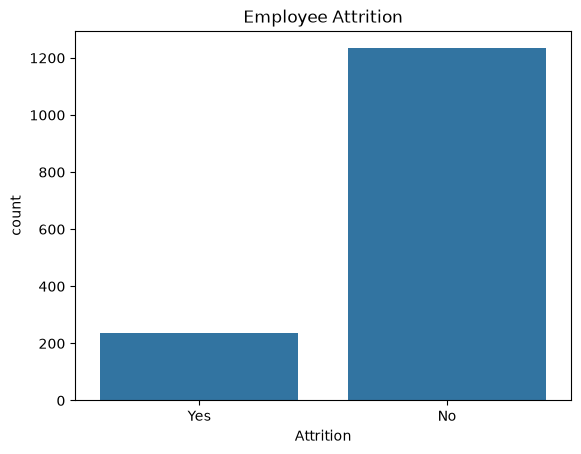

In [34]:
# Data Visualisation

sns.countplot(data=df, x='Attrition')
plt.title('Employee Attrition')
plt.savefig('../visualizations/attrition_distribution.png')
plt.show()

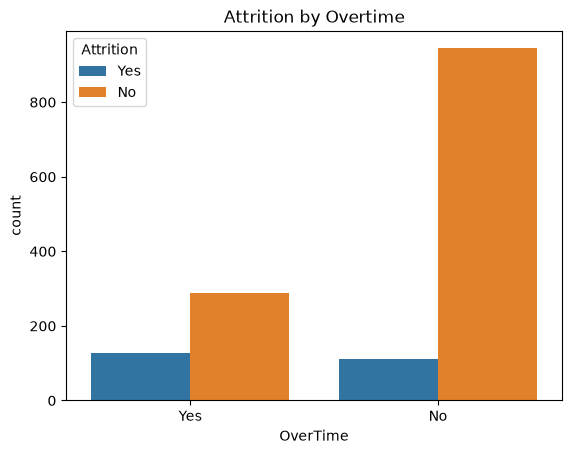

In [35]:
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Attrition by Overtime')
plt.savefig('../visualizations/attrition_overtime.png')
plt.show()

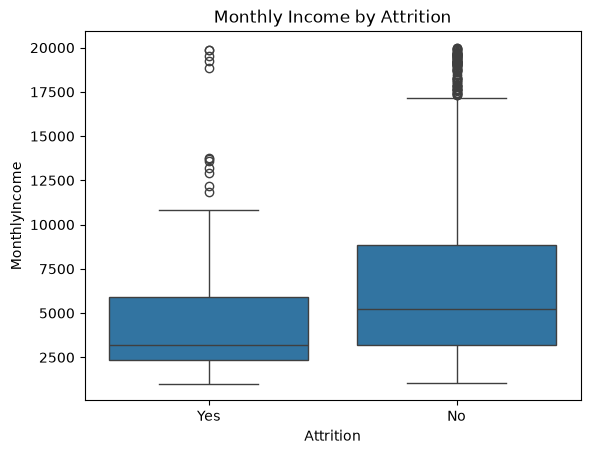

In [36]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income by Attrition')
plt.savefig('../visualizations/income_attrition.png')
plt.show()

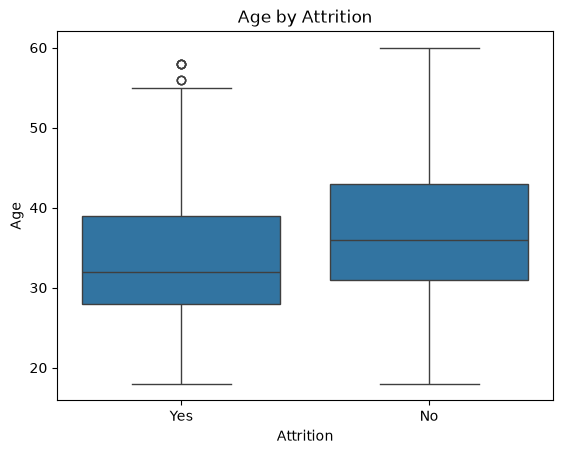

In [37]:
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title('Age by Attrition')
plt.savefig('../visualizations/age_attrition.png')
plt.show()

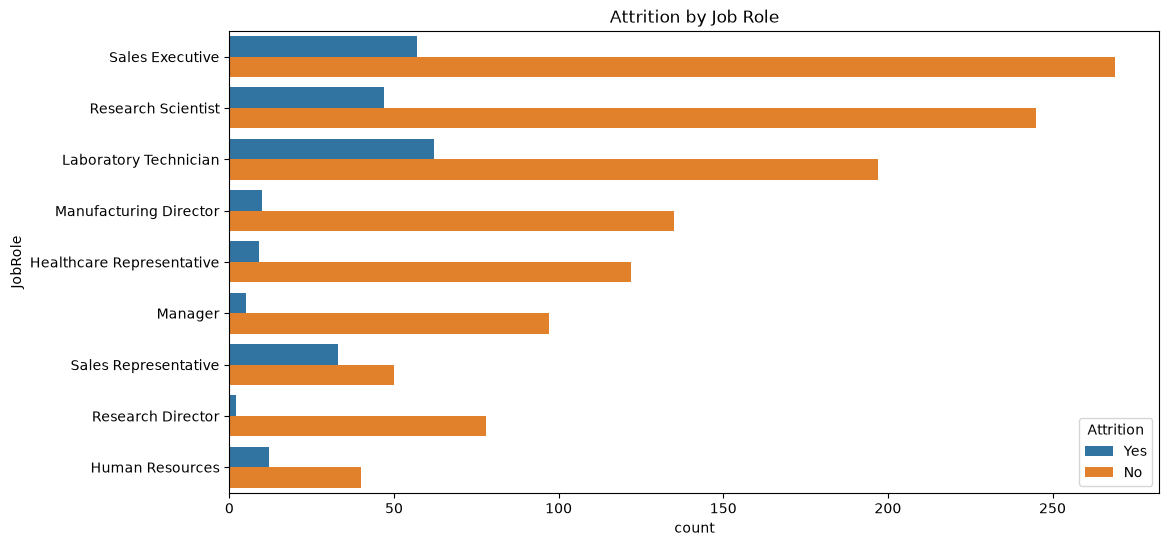

In [38]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='JobRole',
    hue='Attrition'
)

plt.title('Attrition by Job Role')
plt.savefig('../visualizations/jobrole_attrition.png')
plt.show()

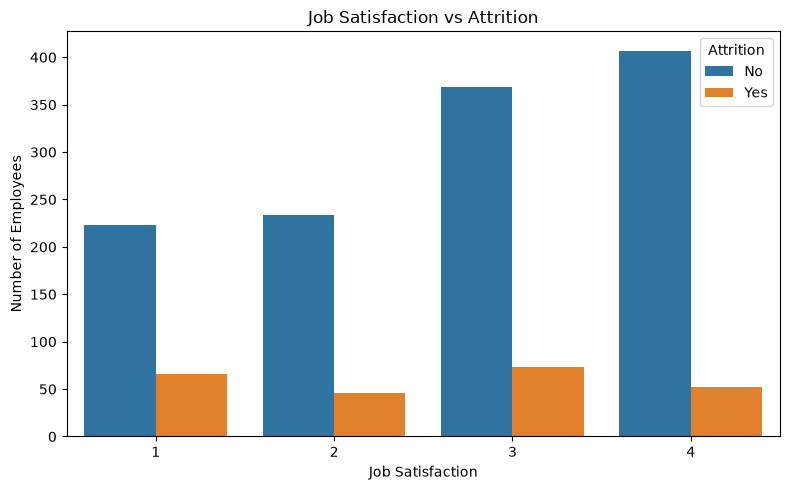

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')

plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction')
plt.ylabel('Number of Employees')

plt.tight_layout()

plt.savefig('../visualizations/Job Satisfaction attrition.png')

plt.show()

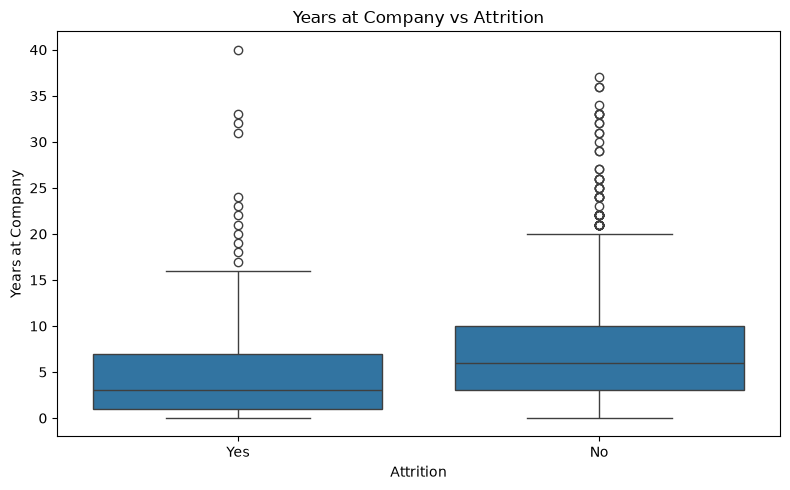

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')

plt.title('Years at Company vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')

plt.tight_layout()

plt.savefig('../visualizations/Years at Company attrition.png')

plt.show()

In [41]:
import os
print(os.getcwd())

c:\Users\pc\Documents\IT-Employee-EDA\notebooks


In [42]:
pd.crosstab(
    [df['OverTime'], df['JobSatisfaction']],
    df['Attrition'],
    normalize='index'
) * 100

Attrition                        No        Yes
OverTime JobSatisfaction                      
No       1                82.439024  17.560976
         2                90.521327   9.478673
         3                90.031153   9.968847
         4                93.059937   6.940063
Yes      1                64.285714  35.714286
         2                62.318841  37.681159
         3                66.115702  33.884298
         4                78.873239  21.126761

In [43]:
df.groupby('Attrition')[
    [
        'Age',
        'MonthlyIncome',
        'JobSatisfaction',
        'DistanceFromHome',
        'YearsAtCompany',
        'TotalWorkingYears',
        'NumCompaniesWorked'
    ]
].mean()

,Age,MonthlyIncome,JobSatisfaction,DistanceFromHome,YearsAtCompany,TotalWorkingYears,NumCompaniesWorked
Attrition,,,,,,,
No,37.561233,6832.739659,2.778589,8.915653,7.369019,11.862936,2.645580
Yes,33.607595,4787.092827,2.468354,10.632911,5.130802,8.244726,2.940928


# Trends, Patterns and Anomalies

The exploratory analysis reveals several patterns in the dataset:

- Employees working overtime show a higher attrition rate than employees who do not work overtime.
- Lower job satisfaction is associated with a higher attrition rate.
- Employees who leave the company have a lower average monthly income.
- Employees who leave the company are younger on average.
- Employees who leave the company have fewer years at the company on average.
- Some job roles show higher attrition levels than others.

## Potential Anomalies and Data Issues

The dataset was also checked for potential data quality problems, including missing values, duplicated rows, and unusual values.

No major data quality issues were identified after the cleaning process.

In [44]:
import scipy
print("SciPy version:", scipy.__version__)

SciPy version: 1.18.1


In [45]:
from scipy.stats import chi2_contingency

# Hypothesis: OverTime is associated with Attrition

table = pd.crosstab(df['OverTime'], df['Attrition'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: There is a statistically significant association between OverTime and Attrition.")
else:
    print("Result: There is no statistically significant association between OverTime and Attrition.")

Chi-square statistic: 87.56429365828768
p-value: 8.15842372153832e-21
Result: There is a statistically significant association between OverTime and Attrition.


In [47]:
from scipy.stats import chi2_contingency

# Hypothesis: Job Satisfaction is associated with Attrition

table = pd.crosstab(df['JobSatisfaction'], df['Attrition'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: There is a statistically significant association between Job Satisfaction and Attrition.")
else:
    print("Result: There is no statistically significant association between Job Satisfaction and Attrition.")

Chi-square statistic: 17.505077010348
p-value: 0.0005563004510387556
Result: There is a statistically significant association between Job Satisfaction and Attrition.


In [46]:
# 7.KEY INSIGHTS

# Attrition rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate:")
print(attrition_rate)

# Attrition by Overtime
print("\nAttrition by Overtime:")
print(pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100)


# Attrition by Job Satisfaction
print("\nAttrition by Job Satisfaction:")
print(pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100)

# Attrition by Monthly Income
print("\nAttrition by Monthly Income:")
print(df.groupby('Attrition')['MonthlyIncome'].mean())

# Attrition by Age
print("\nAttrition by Age:")
print(df.groupby('Attrition')['Age'].mean())

# Attrition by Years at Company
print("\nAttrition by Years at Company:")
print(df.groupby('Attrition')['YearsAtCompany'].mean())

Attrition Rate:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Attrition by Overtime:
Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846

Attrition by Job Satisfaction:
Attrition               No        Yes
JobSatisfaction                      
1                77.162630  22.837370
2                83.571429  16.428571
3                83.484163  16.515837
4                88.671024  11.328976

Attrition by Monthly Income:
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

Attrition by Age:
Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

Attrition by Years at Company:
Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64


# 8. CONCLUSION

The analysis shows that employee attrition is associated with several factors, including overtime, job satisfaction, monthly income, age, and years at the company.

Employees working overtime have a higher attrition rate than those who do not work overtime. Lower job satisfaction is also associated with higher attrition.

Employees who leave the company have lower average monthly income, are younger on average, and have fewer years at the company compared with employees who stay.

These findings can help HR teams identify employees who may be at higher risk of leaving and develop appropriate retention strategies.

However, these results show associations in the dataset and do not prove that these factors directly cause employee attrition.